# Analyzing Government Priorities Extracted From Websites Using NLP and MTP

In [15]:
#Importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Reading the JSON file into a pandas DataFrame
df = pd.read_json('../../data/MTP/ALL_extracted_initiatives_merged.json')
df.head(5)

,municipality_name,topic_id,primary_category,representation,budget_allocation,impacted_stakeholders,summary,related_doc_count
0,Chapel Hill,50,"parks, recreation, and public art","[climbing, wall, belay, belayers, center, old,...",NaN,"[community members, climbers, children, parent...",Chapel Hill's Community Center offers an indoo...,3
1,Chapel Hill,51,"building permits, inspections, and local ordin...","[permit, email, steps, applicant, notification...",NaN,"[applicants, homeowners, contractors, develope...",The Chapel Hill Online Permit Center automatic...,3
2,Chapel Hill,52,"town governance, human resources, and board ap...","[community, webinar, virtual, aesthetics, advo...",NaN,"[Community Design Commission members, Council ...","The Chapel Hill Community Design Commission, w...",3
3,Chapel Hill,53,uncategorized initiatives,"[older, years, age, children, 16, 15, backgrou...",NaN,"[children, parents, volunteers, community orga...",Chapel Hill outlines age requirements for vari...,3
4,Chapel Hill,54,"town governance, human resources, and board ap...","[ordinance, vote, franchise, majority, legisla...",NaN,"[Town Council, residents, property owners, bus...",Chapel Hill's legislative procedures dictate v...,3


In [17]:
# Create a crosstab of primary_category vs municipality_name to see the distribution of initiatives across municipalities and categories
counts_by_category_and_municipality = pd.crosstab(df['primary_category'], df['municipality_name'])

In [18]:
counts_by_category_and_municipality

municipality_name,Carrboro,Chapel Hill,Hillsborough,Mebane,Orange County
primary_category,,,,,
affordable housing and zoning,2,6,0,0,5
"building permits, inspections, and local ordinances",0,7,6,3,1
climate action and clean energy,4,2,1,0,1
job creation and business support,1,1,3,0,0
"parks, recreation, and public art",7,7,7,8,2
"police, fire, and emergency response",6,3,16,6,5
public transportation and roads,10,3,5,1,1
"town governance, human resources, and board appointments",23,20,20,5,15
uncategorized initiatives,3,1,1,1,19


In [34]:
counts_by_category_and_municipality.to_csv('../../data/analysis/counts_by_category_and_municipality.csv', index=True)

## Program Frequency Overall

In [20]:
# Calculate the frequency and percentage of each primary category (program area)
program_area_stats = df['primary_category'].value_counts().reset_index()
program_area_stats.columns = ['program_area', 'initiative_count']

# Add a percentage column for better context
total_initiatives = len(df)
program_area_stats['percentage_of_total'] = (program_area_stats['initiative_count'] / total_initiatives * 100).round(2)

print("Top Program Areas Overall:")
display(program_area_stats.head(15))

Top Program Areas Overall:


,program_area,initiative_count,percentage_of_total
0,"town governance, human resources, and board ap...",83,29.86
1,"waste management, stormwater, and infrastructure",40,14.39
2,"police, fire, and emergency response",36,12.95
3,"parks, recreation, and public art",31,11.15
4,uncategorized initiatives,25,8.99
5,public transportation and roads,20,7.19
6,"building permits, inspections, and local ordin...",17,6.12
7,affordable housing and zoning,13,4.68
8,climate action and clean energy,8,2.88
9,job creation and business support,5,1.80


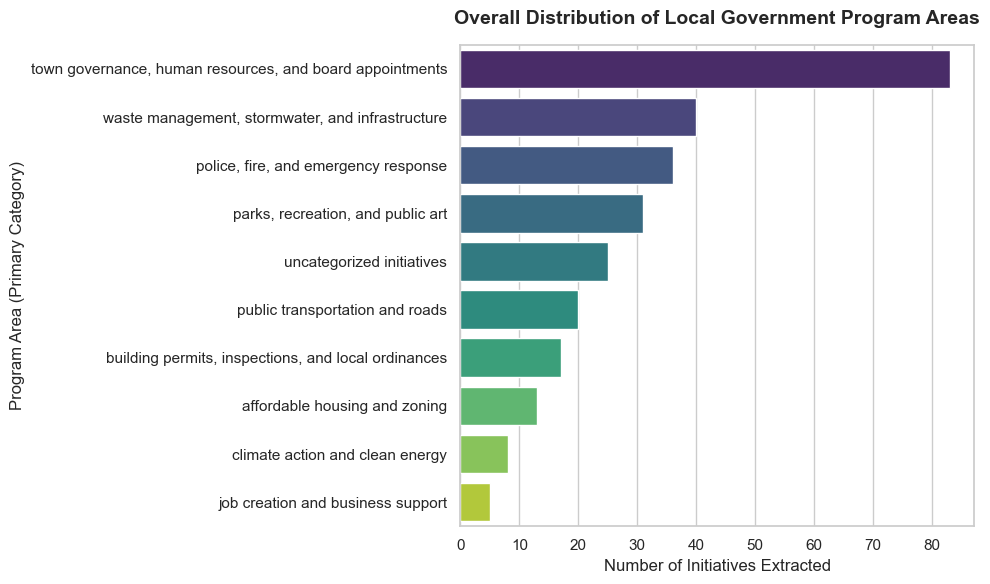

In [21]:
# Set a clean, professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Generate horizontal bar plot
ax = sns.barplot(
    x='initiative_count', 
    y='program_area', 
    data=program_area_stats, 
    palette='viridis',
    hue='program_area',
    legend=False
)

# Titles and labels
plt.title('Overall Distribution of Local Government Program Areas', fontsize=14, pad=15, weight='bold')
plt.xlabel('Number of Initiatives Extracted', fontsize=12)
plt.ylabel('Program Area (Primary Category)', fontsize=12)

plt.tight_layout()
plt.show()

### Top Program Areas by Muni

In [22]:
# Group by municipality and category, get counts, and find the top 3 per municipality
top_categories_per_muni = (
    df.groupby(['municipality_name', 'primary_category'])
    .size()
    .reset_index(name='count')
    .sort_values(['municipality_name', 'count'], ascending=[True, False])
)

# Filter for the top 3 in each municipality group
top_3_per_muni = top_categories_per_muni.groupby('municipality_name').head(3)

print("Top 3 Program Areas for Each Municipality by count:")
display(top_3_per_muni)

Top 3 Program Areas for Each Municipality by count:


,municipality_name,primary_category,count
6,Carrboro,"town governance, human resources, and board ap...",23
5,Carrboro,public transportation and roads,10
3,Carrboro,"parks, recreation, and public art",7
16,Chapel Hill,"town governance, human resources, and board ap...",20
10,Chapel Hill,"building permits, inspections, and local ordin...",7
13,Chapel Hill,"parks, recreation, and public art",7
27,Hillsborough,"waste management, stormwater, and infrastructure",23
25,Hillsborough,"town governance, human resources, and board ap...",20
23,Hillsborough,"police, fire, and emergency response",16
29,Mebane,"parks, recreation, and public art",8


In [23]:
# Create a crosstab normalized by column (municipality) to get percentages
muni_program_percentages = pd.crosstab(
    df['primary_category'], 
    df['municipality_name'], 
    normalize='columns'
) * 100

# Round to 2 decimal places and sort by the total volume across the dataset
muni_program_percentages['Total_Count'] = df['primary_category'].value_counts()
muni_program_percentages = muni_program_percentages.sort_values(by='Total_Count', ascending=False).drop(columns='Total_Count')

print("Program Area Share (%) by Municipality:")
display(muni_program_percentages.round(2))

Program Area Share (%) by Municipality:


municipality_name,Carrboro,Chapel Hill,Hillsborough,Mebane,Orange County
primary_category,,,,,
"town governance, human resources, and board appointments",39.66,35.71,24.39,16.13,29.41
"waste management, stormwater, and infrastructure",3.45,10.71,28.05,22.58,3.92
"police, fire, and emergency response",10.34,5.36,19.51,19.35,9.80
"parks, recreation, and public art",12.07,12.50,8.54,25.81,3.92
uncategorized initiatives,5.17,1.79,1.22,3.23,37.25
public transportation and roads,17.24,5.36,6.10,3.23,1.96
"building permits, inspections, and local ordinances",0.00,12.50,7.32,9.68,1.96
affordable housing and zoning,3.45,10.71,0.00,0.00,9.80
climate action and clean energy,6.90,3.57,1.22,0.00,1.96


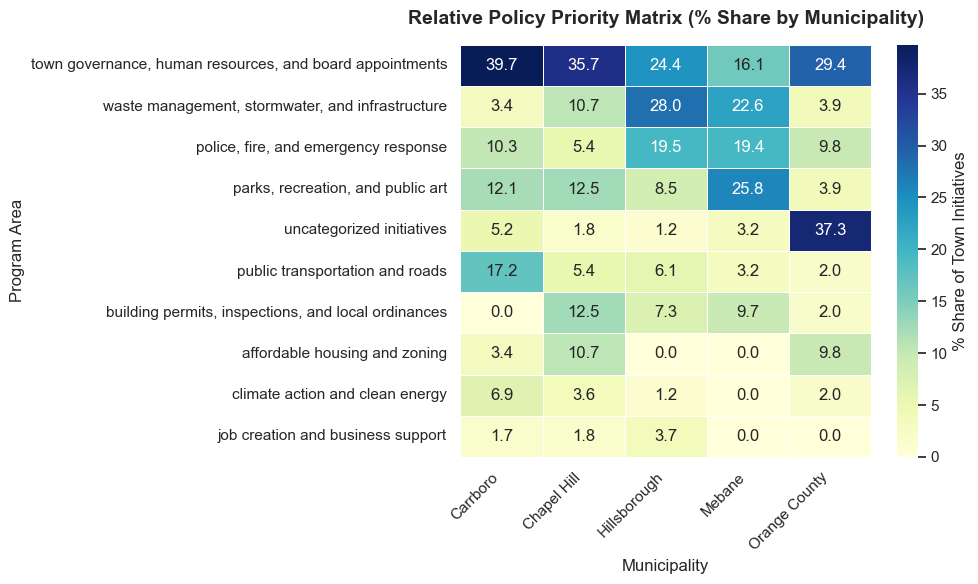

In [24]:
plt.figure(figsize=(10, 6))

# Plot a heatmap of the percentage shares across municipalities
sns.heatmap(
    muni_program_percentages.round(1), 
    annot=True, 
    cmap='YlGnBu', 
    fmt='.1f', 
    linewidths=0.5,
    cbar_kws={'label': '% Share of Town Initiatives'}
)

plt.title('Relative Policy Priority Matrix (% Share by Municipality)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Municipality', fontsize=12)
plt.ylabel('Program Area', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [25]:
# Export the percentage breakdown to CSV
muni_program_percentages.round(2).to_csv('../../data/analysis/muni_program_area_percentages.csv', index=True)

### Initiative Complexity

Calculates how many related "paragraphs" there are on average for each topic area to see if one is more "bloated" than the others.

In [26]:
# Group by primary category and calculate the average and total related documents
complexity_stats = df.groupby('primary_category').agg(
    total_initiatives=('municipality_name', 'count'),
    avg_related_docs=('related_doc_count', 'mean'),
    total_related_docs=('related_doc_count', 'sum')
).reset_index()

# Sort by the highest average document count to find the most complex areas
complexity_stats = complexity_stats.sort_values('avg_related_docs', ascending=False).round(2)

print("Program Areas Ranked by Complexity (Average Related Docs):")
display(complexity_stats.head(15))

Program Areas Ranked by Complexity (Average Related Docs):


,primary_category,total_initiatives,avg_related_docs,total_related_docs
5,"police, fire, and emergency response",36,3.08,111
9,"waste management, stormwater, and infrastructure",40,3.08,123
1,"building permits, inspections, and local ordin...",17,3.06,52
6,public transportation and roads,20,3.05,61
0,affordable housing and zoning,13,3.00,39
2,climate action and clean energy,8,3.00,24
3,job creation and business support,5,3.00,15
4,"parks, recreation, and public art",31,3.00,93
7,"town governance, human resources, and board ap...",83,3.00,249
8,uncategorized initiatives,25,3.00,75


In [27]:
# Export the new statistics to CSV
program_area_stats.to_csv('../../data/analysis/program_area_breakdown.csv', index=False)
complexity_stats.to_csv('../../data/analysis/program_area_complexity.csv', index=False)

## Analyze Stakeholders Mentioned in Initiatives

In [28]:
# Explode the lists in 'impacted_stakeholders' so each individual stakeholder gets its own row
df_exploded = df.explode('impacted_stakeholders')

# Clean the string data: convert to lowercase and strip whitespace to prevent duplicate categories
df_exploded['impacted_stakeholders'] = df_exploded['impacted_stakeholders'].str.lower().str.strip()



### Top Stakeholders Overall

In [29]:
# Calculate the overall frequency of each stakeholder across all municipalities
overall_stakeholder_counts = df_exploded['impacted_stakeholders'].value_counts().reset_index()
overall_stakeholder_counts.columns = ['stakeholder', 'count']

print("Top 15 Most Impacted Stakeholders Overall:")
display(overall_stakeholder_counts.head(15))

Top 15 Most Impacted Stakeholders Overall:


,stakeholder,count
0,residents,105
1,community members,57
2,property owners,36
3,town staff,28
4,developers,25
5,businesses,24
6,town council,23
7,public,20
8,children,11
9,customers,10


### Top Stakeholders by Municipality

In [30]:
# Create a crosstab to analyze stakeholder representation per municipality
stakeholders_vs_municipality = pd.crosstab(
    df_exploded['impacted_stakeholders'], 
    df_exploded['municipality_name']
)

# Add a 'Total' column to sort by overall frequency, then drop it for a cleaner display
stakeholders_vs_municipality['Total'] = stakeholders_vs_municipality.sum(axis=1)
stakeholders_vs_municipality = stakeholders_vs_municipality.sort_values('Total', ascending=False).drop(columns='Total')

print("Top 15 Stakeholders Breakdown by Municipality:")
display(stakeholders_vs_municipality.head(15))

Top 15 Stakeholders Breakdown by Municipality:


municipality_name,Carrboro,Chapel Hill,Hillsborough,Mebane,Orange County
impacted_stakeholders,,,,,
residents,39,26,24,10,6
community members,14,9,16,5,13
property owners,2,14,18,1,1
town staff,8,14,6,0,0
developers,1,11,8,4,1
businesses,6,5,9,2,2
town council,10,13,0,0,0
public,0,8,11,1,0
children,2,3,2,3,1


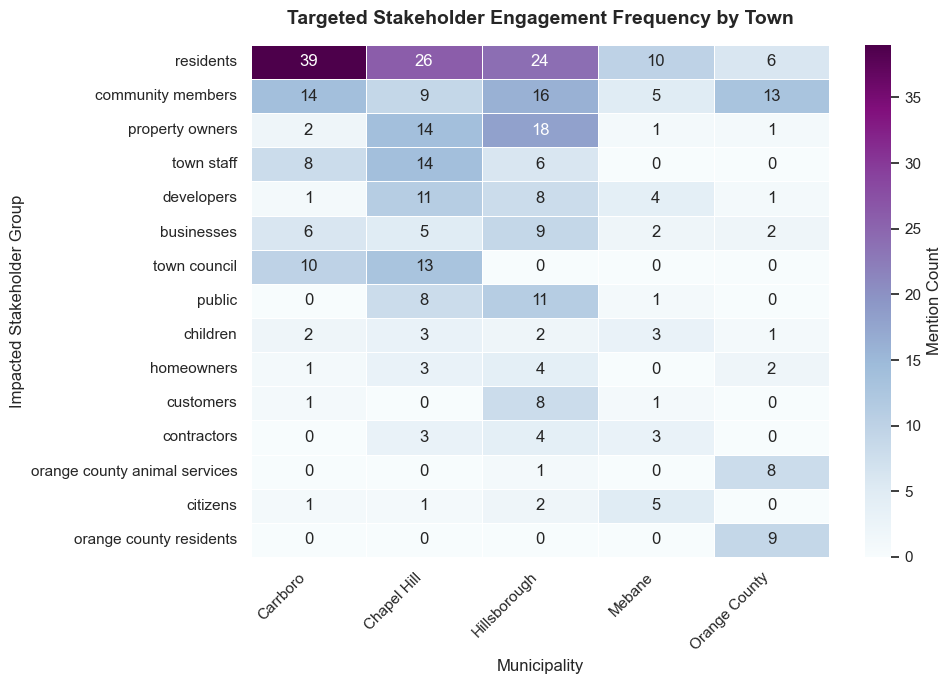

In [31]:
plt.figure(figsize=(10, 7))

# Get top 15 stakeholders to keep the visual tidy and insightful
top_15_stakeholders_df = stakeholders_vs_municipality.head(15)

sns.heatmap(
    top_15_stakeholders_df, 
    annot=True, 
    cmap='BuPu', 
    fmt='d', 
    linewidths=0.5,
    cbar_kws={'label': 'Mention Count'}
)

plt.title('Targeted Stakeholder Engagement Frequency by Town', fontsize=14, pad=15, weight='bold')
plt.xlabel('Municipality', fontsize=12)
plt.ylabel('Impacted Stakeholder Group', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Stakeholders by Initiative

In [32]:
# Cross-reference stakeholders with the primary initiative categories
stakeholders_vs_categories = pd.crosstab(
    df_exploded['impacted_stakeholders'], 
    df_exploded['primary_category']
)

# Sort by the most frequently occurring stakeholders
stakeholders_vs_categories['Total'] = stakeholders_vs_categories.sum(axis=1)
stakeholders_vs_categories = stakeholders_vs_categories.sort_values('Total', ascending=False).drop(columns='Total')

display(stakeholders_vs_categories.head(15))

primary_category,affordable housing and zoning,"building permits, inspections, and local ordinances",climate action and clean energy,job creation and business support,"parks, recreation, and public art","police, fire, and emergency response",public transportation and roads,"town governance, human resources, and board appointments",uncategorized initiatives,"waste management, stormwater, and infrastructure"
impacted_stakeholders,,,,,,,,,,
residents,5,9,2,1,9,13,10,34,6,16
community members,1,2,4,0,13,7,3,14,9,4
property owners,2,9,2,0,0,1,1,5,0,16
town staff,2,4,1,0,0,0,0,17,0,4
developers,3,10,0,1,0,0,0,4,0,7
businesses,0,5,3,1,2,4,2,3,0,4
town council,1,0,1,0,1,0,2,18,0,0
public,0,3,0,0,3,2,0,11,0,1
children,0,0,0,0,3,6,0,0,1,1


In [33]:
# Export the cross-tabulations to CSV for external visualization
stakeholders_vs_municipality.to_csv('../../data/analysis/stakeholders_vs_municipality.csv', index=True)
stakeholders_vs_categories.to_csv('../../data/analysis/stakeholders_vs_categories.csv', index=True)